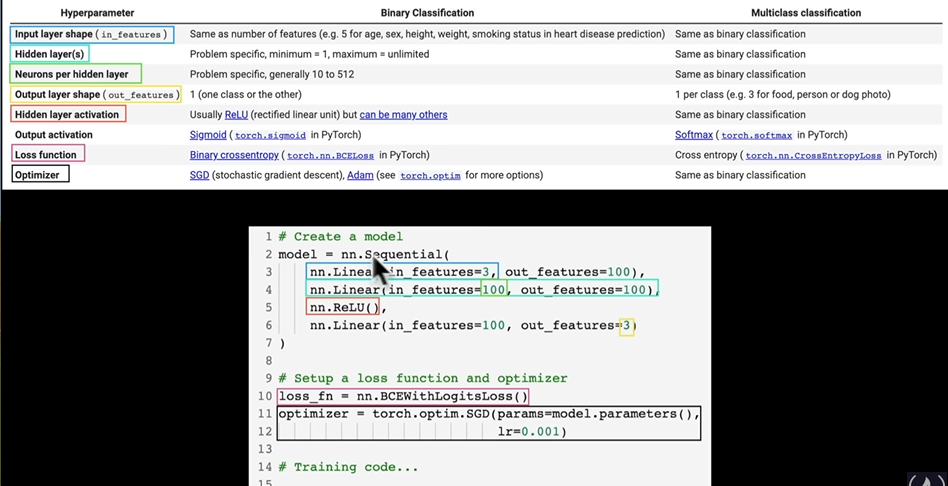

# 02. Neural Network classification with PyTorch

Classification is a problem of predicting whether something is one thing or another (there can be multiple things as the options).

In [51]:
import sklearn
from sklearn.datasets import make_circles


In [52]:
n_samples = 1000

X,y = make_circles(n_samples,noise=0.03,random_state=42)

len(X),len(y)

(1000, 1000)

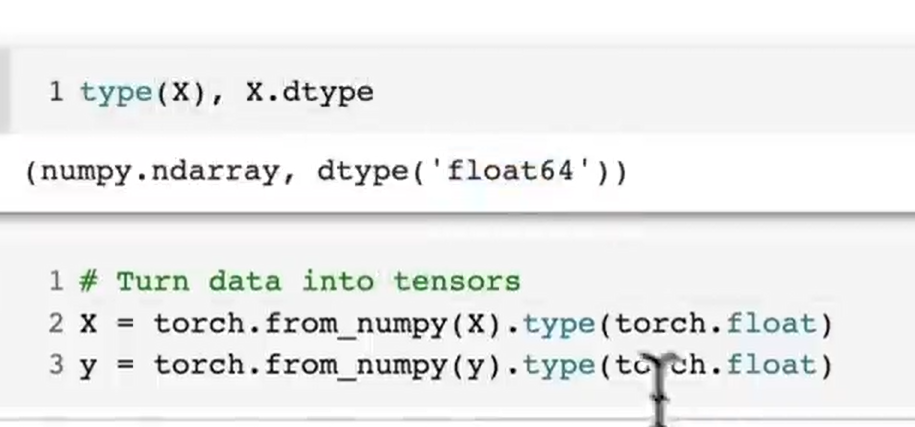

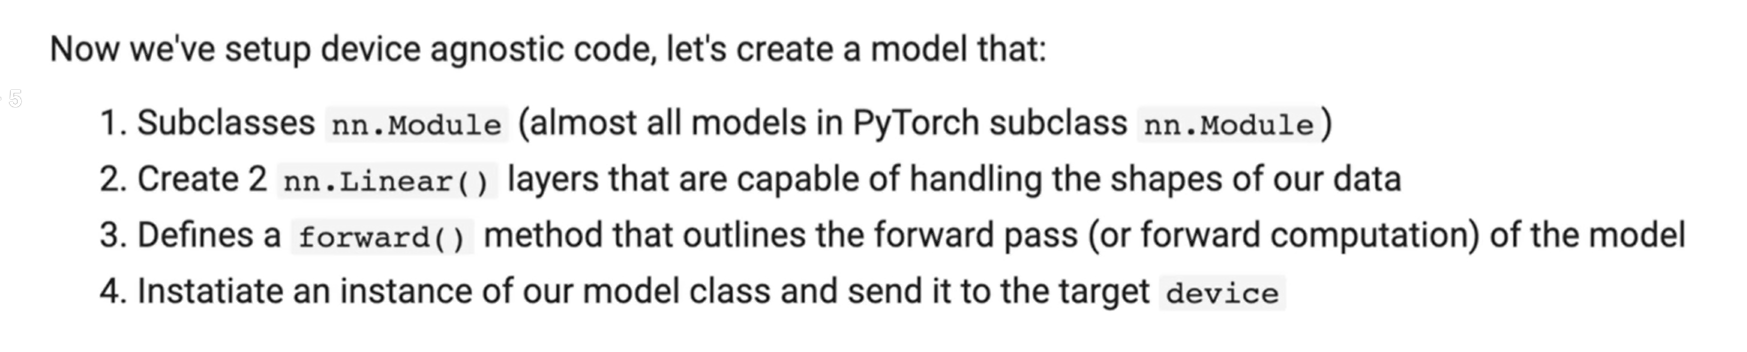

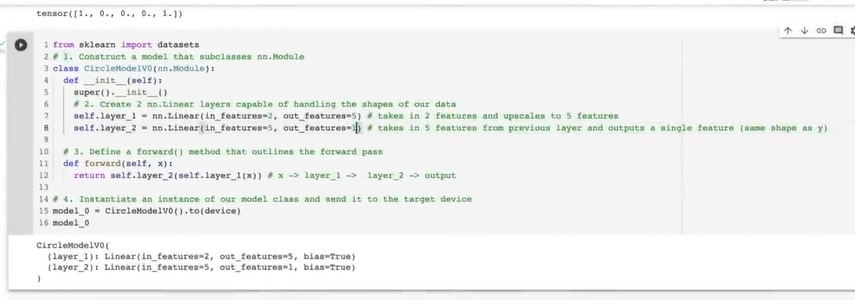

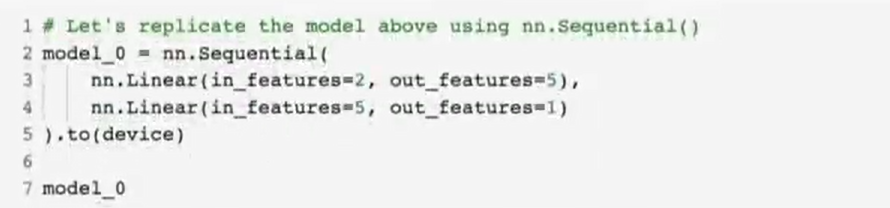

### 8. Putting it all together with a multi-class classification problem

* Binary classification = one thing or another (cat vs. dog, spam vs. not spam, fraud or not fraud)
* Multi-class classification = more than one thing or another (cat vs. dog vs. chicken)

### 8.1 Creating a toy multi-class dataset

In [53]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

#Set up Hyperparameters
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

#Create a multiclass data

X_blob , y_blob =  make_blobs(n_samples=1000,
                              n_features=NUM_FEATURES,
                              centers=NUM_CLASSES,
                              cluster_std = 1.5,
                              random_state=RANDOM_SEED)

#Turn data into tensors

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

In [54]:
# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                          y_blob,
                                                                          test_size=0.2,
                                                                          random_state=RANDOM_SEED)

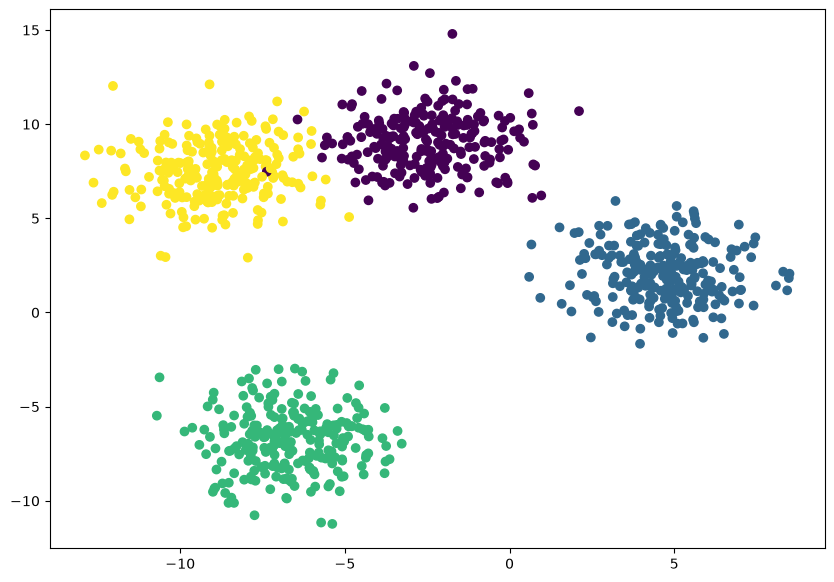

In [55]:
# 4. Plot data (visualize, visualize, visualize)
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob)

### 8.2 Building a multiclass classification model in pytorch

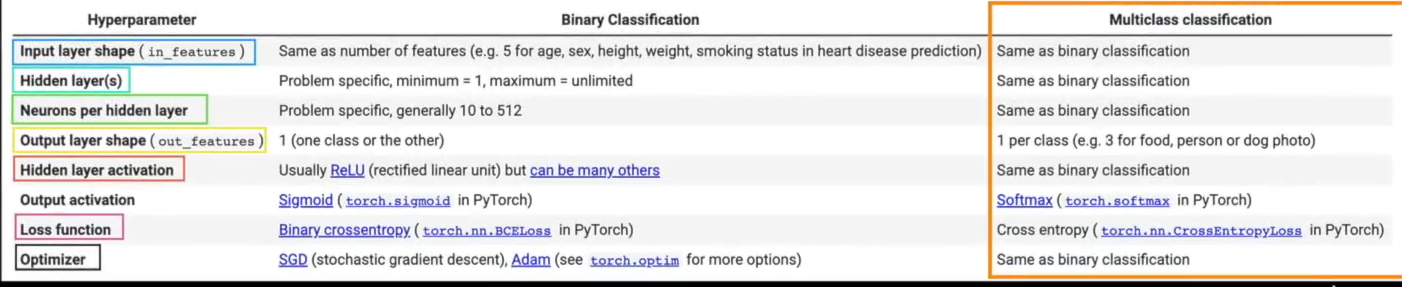

In [56]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [57]:
# Build a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    """Initializes multi-class classification model.

    Args:
      input_features (int): Number of input features to the model
      output_features (int): Number of outputs features (number of output classes)
      hidden_units (int): Number of hidden units between layers, default 8

    Returns:

    Example:
    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=2,
                    output_features=4,
                     hidden_units=8 ).to(device)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [58]:
torch.unique(y_blob_train)

tensor([0., 1., 2., 3.])

In [59]:
## 8.3 Create a loss funuction and optimizer for amulticlass classification model

loss_fn = nn.CrossEntropyLoss()

#Create an optimizer for multiclass 
optimizer = torch.optim.SGD(params=model_4.parameters(),lr=0.1)

### 8.4 Getting pred prob for multiclass pytorch model

In order to evaluate and train and test our model, we need to convert our model's outputs (logits) to prediction probabilities and then to prediction labels.

Logits (raw output of the model) -> Pred probs (use `torch.softmax`) -> Pred labels (take the argmax of the prediction probabilities)

In [60]:

with torch.inference_mode():
    y_logits = model_4(X_blob_test)

y_logits

tensor([[ 1.4935,  0.8420, -0.2486,  0.0396],
        [ 1.2605,  0.9023, -0.1113, -0.9386],
        [ 0.5273,  2.2153,  0.7560,  0.0334],
        [ 0.9077,  0.4841, -0.2136,  0.0812],
        [ 2.1901,  1.2250, -0.2205, -0.8960],
        [ 1.4333,  1.0762, -0.0961, -1.1397],
        [ 0.5275,  1.9793,  0.6455,  0.2242],
        [ 1.7540,  1.0240, -0.1882, -0.9482],
        [ 0.5367,  2.6932,  0.9751, -0.2334],
        [ 1.8763,  1.0756, -0.1964, -0.9079],
        [ 1.5759,  0.9482, -0.1995, -0.9165],
        [ 1.6463,  0.9419, -0.2762,  0.0252],
        [ 2.1342,  1.2080, -0.2144, -0.9579],
        [ 2.0671,  1.1990, -0.2051, -1.1031],
        [ 2.2702,  1.3084, -0.2184, -1.1739],
        [ 1.2152,  0.8509, -0.1109, -0.8649],
        [ 1.2765,  0.9234, -0.1110, -0.9585],
        [ 0.4425,  1.4807,  0.4378, -0.0879],
        [ 1.5034,  1.0662, -0.0972, -1.1835],
        [ 0.9795,  0.9543, -0.0637, -0.6634],
        [ 1.4361,  0.9825, -0.1209, -1.0418],
        [ 1.3996,  0.8221, -0.1867

In [61]:
#Convert our model logic outputs to prediction prob 

y_pred_probs = torch.softmax(y_logits,dim=1)
print(y_logits[:5])
print (y_pred_probs[:5])

tensor([[ 1.4935,  0.8420, -0.2486,  0.0396],
        [ 1.2605,  0.9023, -0.1113, -0.9386],
        [ 0.5273,  2.2153,  0.7560,  0.0334],
        [ 0.9077,  0.4841, -0.2136,  0.0812],
        [ 2.1901,  1.2250, -0.2205, -0.8960]])
tensor([[0.5181, 0.2701, 0.0907, 0.1211],
        [0.4846, 0.3387, 0.1229, 0.0537],
        [0.1208, 0.6535, 0.1519, 0.0737],
        [0.4135, 0.2707, 0.1348, 0.1810],
        [0.6595, 0.2512, 0.0592, 0.0301]])


In [62]:
torch.sum(y_pred_probs[0])
torch.max(y_pred_probs[0])

tensor(0.5181)

In [68]:
y_preds = torch.argmax(y_pred_probs,dim=1)
y_preds

tensor([0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
        1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
        1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
        1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
        1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
        0, 0, 1, 0, 0, 0, 1, 0])

In [69]:
y_blob_test

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0., 0., 1., 0., 0., 0., 3., 3., 2.,
        3., 3., 3., 0., 1., 2., 2., 2., 3., 0., 1., 0., 3., 1., 1., 3., 1., 2.,
        1., 3., 0., 2., 0., 3., 3., 2., 0., 3., 1., 1., 0., 3., 1., 0., 1., 1.,
        3., 2., 1., 1., 3., 2., 2., 0., 3., 2., 2., 0., 0., 3., 3., 0., 0., 3.,
        3., 3., 2., 3., 3., 3., 3., 1., 0., 2., 3., 2., 3., 3., 2., 3., 3., 2.,
        3., 3., 1., 3., 3., 3., 1., 0., 3., 2., 0., 0., 3., 0., 2., 3., 1., 0.,
        3., 2., 1., 1., 0., 2., 2., 3., 0., 0., 1., 2., 2., 3., 0., 1., 2., 0.,
        0., 0., 2., 3., 1., 2., 3., 2., 0., 3., 0., 0., 1., 1., 1., 0., 2., 2.,
        2., 2., 0., 3., 3., 2., 2., 1., 3., 2., 0., 0., 3., 3., 2., 1., 2., 0.,
        3., 2., 0., 3., 2., 0., 2., 2., 2., 0., 3., 1., 1., 1., 1., 1., 3., 1.,
        0., 2., 2., 1., 2., 2., 0., 1., 2., 2., 0., 0., 1., 3., 2., 0., 3., 1.,
        2., 1.])

### Create a training and testing loop for multiclass pytorch model

In [75]:
y_blob_train = y_blob_train.type(torch.LongTensor)
y_blob_test = y_blob_test.type(torch.LongTensor)

In [76]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):  # fixed: was `range(len(epochs))` — epochs is an int, not iterable
    model_4.train()

    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                       y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_blob_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)  # fixed: moved inside inference_mode block

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test,
                                y_pred=test_preds)  # fixed: was using train y_pred instead of test_preds

    # Print out what's happenin'
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test loss: {test_loss:.4f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.6758, Acc: 25.12% | Test loss: 1.2277, Test acc: 50.50%
Epoch: 10 | Loss: 0.7032, Acc: 71.25% | Test loss: 0.6307, Test acc: 78.00%
Epoch: 20 | Loss: 0.2952, Acc: 98.62% | Test loss: 0.2451, Test acc: 99.50%
Epoch: 30 | Loss: 0.1262, Acc: 98.88% | Test loss: 0.1094, Test acc: 99.50%
Epoch: 40 | Loss: 0.0812, Acc: 99.00% | Test loss: 0.0705, Test acc: 99.50%
Epoch: 50 | Loss: 0.0628, Acc: 98.88% | Test loss: 0.0537, Test acc: 99.50%
Epoch: 60 | Loss: 0.0532, Acc: 99.00% | Test loss: 0.0443, Test acc: 99.50%
Epoch: 70 | Loss: 0.0473, Acc: 99.00% | Test loss: 0.0385, Test acc: 99.50%
Epoch: 80 | Loss: 0.0434, Acc: 99.00% | Test loss: 0.0345, Test acc: 99.50%
Epoch: 90 | Loss: 0.0405, Acc: 99.00% | Test loss: 0.0314, Test acc: 99.50%


In [78]:
### 8.6 Making andn evaluating pred with pytorch multiclass model
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

y_logits[:10]


tensor([[ 3.5067,  8.9516, -2.9559, -4.8480],
        [ 2.7236, -4.2664,  0.8980,  7.8657],
        [-3.4372, -0.2568,  8.8746,  1.7270],
        [ 1.3227,  5.4903, -1.5536, -2.3850],
        [ 8.3884,  3.2918, -3.5875, -1.6521],
        [ 3.0046, -5.2433,  1.2869,  9.4387],
        [-3.3458,  0.2008,  7.9968,  1.0194],
        [ 7.1455,  0.3840, -2.6146,  1.0366],
        [-3.8579, -0.8969, 10.7748,  2.7595],
        [ 7.5772,  0.9970, -2.9302,  0.0797]])

In [79]:
#logits -> prob
y_pred_probs = torch.softmax(y_logits,dim=1)
y_pred_probs[:10]

tensor([[4.2997e-03, 9.9569e-01, 6.7106e-06, 1.0117e-06],
        [5.8061e-03, 5.3473e-06, 9.3544e-04, 9.9325e-01],
        [4.4946e-06, 1.0812e-04, 9.9910e-01, 7.8602e-04],
        [1.5234e-02, 9.8353e-01, 8.5837e-04, 3.7377e-04],
        [9.9387e-01, 6.0801e-03, 6.2555e-06, 4.3332e-05],
        [1.6028e-03, 4.1965e-07, 2.8767e-04, 9.9811e-01],
        [1.1841e-05, 4.1082e-04, 9.9865e-01, 9.3150e-04],
        [9.9657e-01, 1.1536e-03, 5.7514e-05, 2.2154e-03],
        [4.4153e-07, 8.5289e-06, 9.9966e-01, 3.3025e-04],
        [9.9803e-01, 1.3848e-03, 2.7281e-05, 5.5340e-04]])

In [80]:
#Prob to labels
y_preds = torch.argmax(y_pred_probs,dim=1)
y_preds

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 0, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

In [81]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

In [92]:
import requests
from pathlib import Path
from helper_functions import plot_predictions, plot_decision_boundary

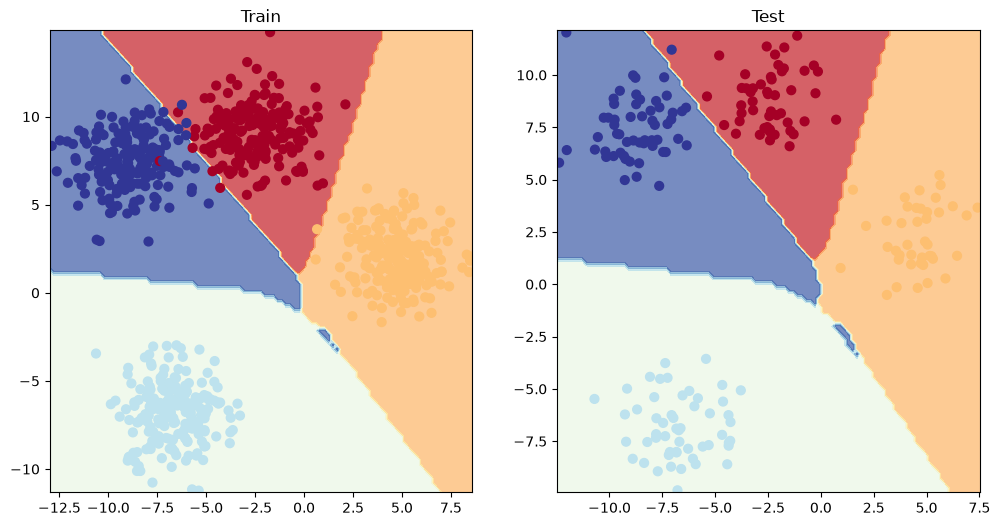

In [93]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 9. A few more classification metrics... (to evaluate our classification model)

* **Accuracy** - out of 100 samples, how many does our model get right? Good default metric for balanced classification problems.
* **Precision** - out of all the positive predictions, how many were actually positive? Higher precision leads to fewer false positives.
* **Recall** - out of all the actual positive samples, how many did the model correctly predict? Higher recall leads to fewer false negatives.
* **F1-score** - combines precision and recall into a single metric (harmonic mean), useful when you need a balance between the two, especially with imbalanced classes.
* **Confusion matrix** - a table comparing predicted labels vs. actual labels, showing true positives, true negatives, false positives, and false negatives.
* **Classification report** - a summary that shows precision, recall, F1-score (and support) for each class in your dataset.

In [96]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [97]:
%pip install torchmetrics

   ---------------------------------------- 0.0/983.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/983.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/983.4 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/983.4 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/983.4 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/983.4 kB ? eta -:--:--
   -------------------- ----------------- 524.3/983.4 kB 342.7 kB/s eta 0:00:02
   -------------------- ----------------- 524.3/983.4 kB 342.7 kB/s eta 0:00:02
   -------------------- ----------------- 524.3/983.4 kB 342.7 kB/s eta 0:00:02
   -------------------- ----------------- 524.3/983.4 kB 342.7 kB/s eta 0:00:02
   -------------------- ----------------- 524.3/983.4 kB 342.7 kB/s eta 0:00:02
   -------------------- ----------------- 524.3/983.4 kB 342.7 kB/s eta 0:00:02
   -------------------- ----------------- 524.3/983.4 kB 342.7 kB/s eta 0:00:02
   -----

In [98]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
